In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [62]:
df=pd.read_excel("/content/Employees.xlsx")

#Show first 5 row from the data

In [63]:
df.head()

,No,First Name,Last Name,Gender,Start Date,Years,Department,Country,Center,Monthly Salary,Annual Salary,Job Rate,Overtime Hours
0,1,ahmed,shady,Male,2018-04-04,7,Quality Control,Egypt,West,1560,18720,3.0,183
1,2,Omar,Hishan,Male,2020-05-21,5,Quality Control,Saudi Arabia,West,3247,38964,1.0,198
2,3,Ailya,Sharaf,Female,2017-09-28,8,Major Mfg Projects,Saudi Arabia,West,2506,30072,2.0,192
3,4,Lwiy,Qbany,Male,2018-08-14,7,Manufacturing,United Arab Emirates,Main,1828,21936,3.0,7
4,5,Ahmad,Bikri,Male,2020-03-11,6,Manufacturing,Egypt,Main,970,11640,5.0,121


#Give me some info about the data

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 689 entries, 0 to 688
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   No              689 non-null    int64         
 1   First Name      689 non-null    object        
 2   Last Name       689 non-null    object        
 3   Gender          689 non-null    object        
 4   Start Date      689 non-null    datetime64[ns]
 5   Years           689 non-null    int64         
 6   Department      689 non-null    object        
 7   Country         689 non-null    object        
 8   Center          689 non-null    object        
 9   Monthly Salary  689 non-null    int64         
 10  Annual Salary   689 non-null    int64         
 11  Job Rate        689 non-null    float64       
 12  Overtime Hours  689 non-null    int64         
dtypes: datetime64[ns](1), float64(1), int64(5), object(6)
memory usage: 70.1+ KB


# Describe important information about your numerical data

In [65]:
df.describe()

,No,Start Date,Years,Monthly Salary,Annual Salary,Job Rate,Overtime Hours
count,689.000000,689,689.000000,689.000000,689.000000,689.000000,689.000000
mean,345.000000,2019-01-25 09:20:06.966618368,6.667634,2068.201742,24818.420900,3.586357,13.702467
min,1.000000,2016-01-08 00:00:00,5.000000,703.000000,8436.000000,1.000000,0.000000
25%,173.000000,2018-04-05 00:00:00,6.000000,1436.000000,17232.000000,3.000000,3.000000
50%,345.000000,2019-04-03 00:00:00,6.000000,2077.000000,24924.000000,3.000000,7.000000
75%,517.000000,2019-12-22 00:00:00,7.000000,2682.000000,32184.000000,5.000000,10.000000
max,689.000000,2020-12-29 00:00:00,10.000000,3450.000000,41400.000000,5.000000,198.000000
std,199.041453,NaN,1.262662,763.289240,9159.470878,1.350125,25.692049


#what the shape of the data

In [66]:
df.shape

(689, 13)

# Give me Random FullName values

In [67]:
df['full_name']=df['First Name']+" "+df['Last Name']

In [68]:
df.sample(5)

,No,First Name,Last Name,Gender,Start Date,Years,Department,Country,Center,Monthly Salary,Annual Salary,Job Rate,Overtime Hours,full_name
197,198,Ibrahim,Alhamid,Male,2020-11-06,5,Major Mfg Projects,Lebanon,West,997,11964,5.0,68,Ibrahim Alhamid
632,633,Rasha,Alrifaei,Female,2019-01-22,7,Account Management,Egypt,North,1661,19932,5.0,9,Rasha Alrifaei
110,111,Mari,Ayly,Female,2016-04-20,9,Account Management,Saudi Arabia,North,1639,19668,5.0,2,Mari Ayly
396,397,Khalid,Iibrahim,Male,2017-02-15,9,Environmental Health/Safety,United Arab Emirates,South,1521,18252,5.0,3,Khalid Iibrahim
31,32,Ghalib,Zakianiin,Male,2019-05-19,6,Environmental Compliance,Syria,North,3151,37812,3.0,48,Ghalib Zakianiin


#KPIS

####1- what is the total salaries paid monthly
####2- what is the total number of Employees
####3- what is the total salaries paid annualy
####4- how many department in the company
####5- what is the average of YOE
####6- how many hours (overtime)
####7- how many employee from each country  

In [69]:
#what is the total salaries paid monthly
total_salary=df['Monthly Salary'].sum()
total_salary

np.int64(1424991)

In [70]:
# what is the total number of Employees
total_emp=df['full_name'].nunique()
total_emp

675

In [71]:
#what is the total salaries paid annualy
total_salary_annualy=df['Annual Salary'].sum()
total_salary_annualy

np.int64(17099892)

In [72]:
#how many department in the company
total_dep=df['Department'].nunique()
print(total_dep)
Dep=df['Department'].unique()
print(Dep)

20
['Quality Control' 'Major Mfg Projects' 'Manufacturing'
 'Product Development' 'Sales' 'Account Management' 'Green Building' 'IT'
 'Facilities/Engineering' 'Marketing' 'Manufacturing Admin' 'Training'
 'Quality Assurance' 'Professional Training Group'
 'Environmental Compliance' 'Creative' 'Research/Development'
 'Environmental Health/Safety' 'Human Resources' 'Research Center']


In [73]:
# what is the average of YOE
average_yoe=df['Years'].mean()
average_yoe

np.float64(6.667634252539913)

In [74]:
# how many hours (overtime)
total_hours=df['Overtime Hours'].sum()
total_hours

np.int64(9441)

In [75]:
# how many employee from each country
df['Country'].value_counts()

,count
Country,
Egypt,379
United Arab Emirates,156
Saudi Arabia,90
Syria,53
Lebanon,11


#Analysis , Answer the following Questions

####1- what is the total salary in each department

In [76]:
salary_dep=df.groupby('Department',as_index=False)['Monthly Salary'].sum()
salary_dep

,Department,Monthly Salary
0,Account Management,162722
1,Creative,38215
2,Environmental Compliance,32606
3,Environmental Health/Safety,18004
4,Facilities/Engineering,132546
5,Green Building,16663
6,Human Resources,17891
7,IT,84581
8,Major Mfg Projects,17939
9,Manufacturing,280649


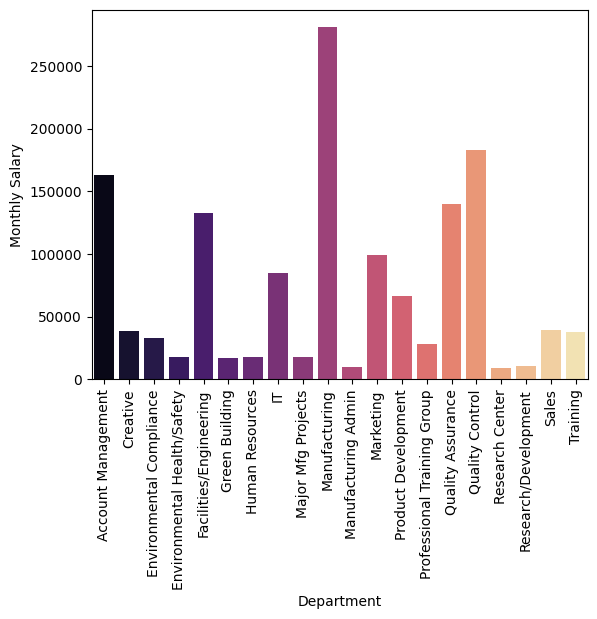

In [77]:
chart=sns.barplot(data=salary_dep,x='Department',y='Monthly Salary',palette='magma')
plt.xticks(rotation=90)
plt.show()

####2-what is the total salary in each Country

In [78]:
salary_Country=df.groupby('Country',as_index=False)['Monthly Salary'].sum()
salary_Country

,Country,Monthly Salary
0,Egypt,792072
1,Lebanon,21886
2,Saudi Arabia,182546
3,Syria,106797
4,United Arab Emirates,321690


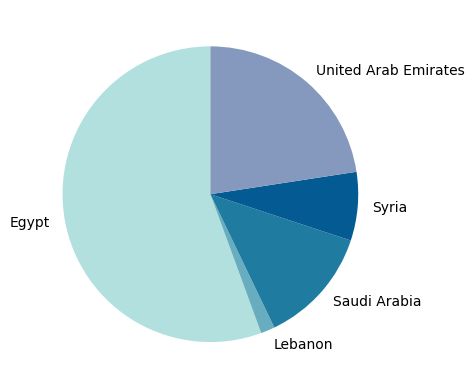

In [79]:
plt.pie(
    salary_Country['Monthly Salary'],
    labels=salary_Country['Country'],
    colors=['#b2e0de','#68adbf','#1f7ca0','#045a93','#8499bd'],
    startangle=90
)
plt.show()

####3-OverTime by Gender

In [80]:
over_time=df.groupby('Gender',as_index=False)['Overtime Hours'].sum()
over_time


,Gender,Overtime Hours
0,Female,2958
1,Male,6483


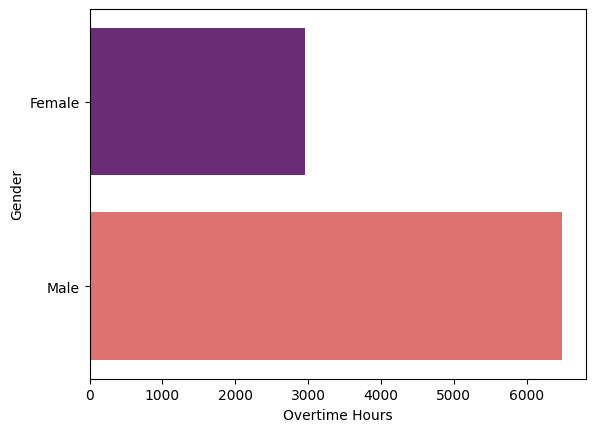

In [81]:
chart=sns.barplot(data=over_time,y='Gender',x='Overtime Hours',palette='magma')
plt.show()

####4- YOE by Country

In [82]:

YOE_Country=df.groupby('Country',as_index=False)['Years'].median()
YOE_Country

,Country,Years
0,Egypt,6.0
1,Lebanon,6.0
2,Saudi Arabia,6.0
3,Syria,7.0
4,United Arab Emirates,6.0


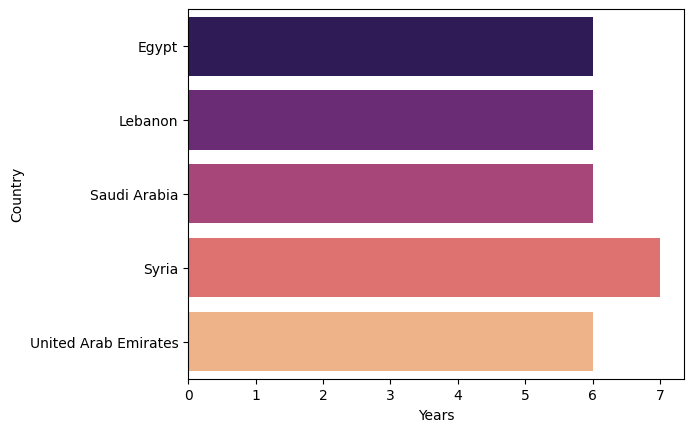

In [84]:
chart=sns.barplot(data=YOE_Country,y='Country',x='Years',palette='magma')
plt.show()

####5-Rating Each department

In [86]:
rating=df.groupby('Department',as_index=False)['Job Rate'].mean()
rating

,Department,Job Rate
0,Account Management,3.690476
1,Creative,3.789474
2,Environmental Compliance,3.076923
3,Environmental Health/Safety,4.222222
4,Facilities/Engineering,3.620690
5,Green Building,2.875000
6,Human Resources,4.357143
7,IT,3.600000
8,Major Mfg Projects,4.250000
9,Manufacturing,3.535714


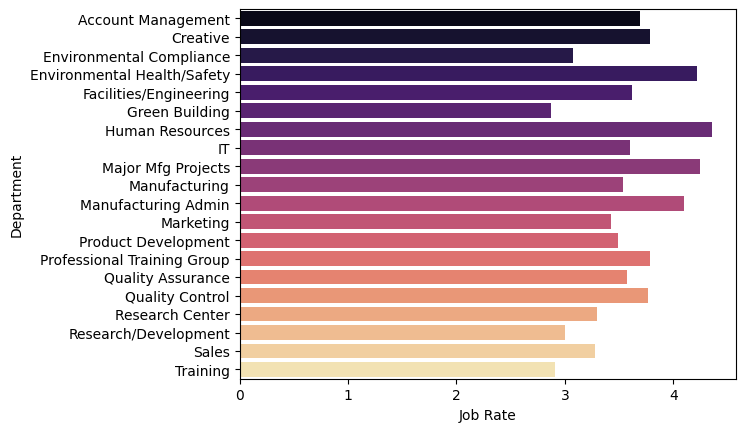

In [87]:
chart=sns.barplot(data=rating,y='Department',x='Job Rate',palette='magma')
plt.show()

####Relation between overhours & job rate

In [94]:
hours_rate=df.groupby('Job Rate',as_index=False)['Overtime Hours'].mean()
hours_rate

,Job Rate,Overtime Hours
0,1.0,14.185714
1,2.0,12.402778
2,3.0,14.235577
3,4.5,15.717742
4,5.0,12.302326


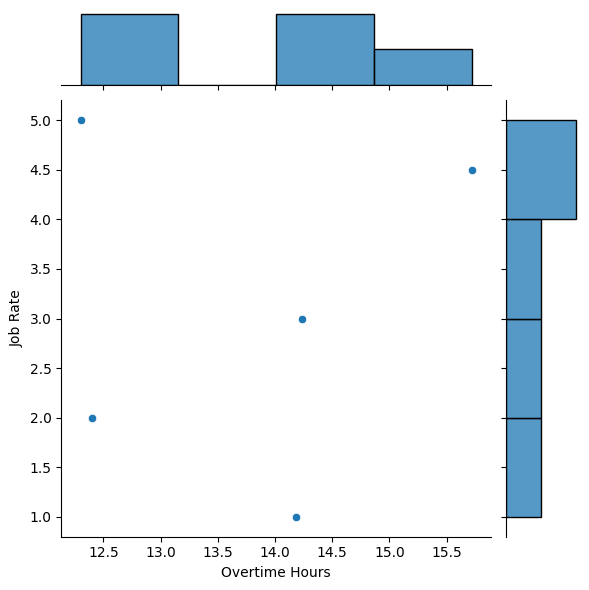

In [95]:
sns.jointplot(x='Overtime Hours',y='Job Rate' ,data=hours_rate,kind='scatter')
plt.show()